# Preface
If you are new to Colab, please familiarize yourself with it by starting with the introduction (https://colab.research.google.com/notebooks/intro.ipynb) and then working yourself through a small tutorial:
https://colab.research.google.com/drive/1umhPVtUWH8yHD2l9A_G4fdttmgmSgC0Q

Please, always save a copy of the notebook on your google drive before you start working and only edit that one. In addition, always switch the runtime to Python 3 and for most **later** exercises it is recommended to also switch to a GPU runtime.

**Important**: Make sure **not** to spend up your GPU resources for earlier tasks that could also easily run on a CPU.

# Exercise 1 - Machine Learning Basics

Link to my file is here;  
https://colab.research.google.com/drive/1vDxywiDYDTTjbCBTyQAX9UotPQsz18NQ?usp=sharing

In the first part of this exercise we will will apply linear regression to a dataset of brain properties. In the second part we will apply logistic regresseion to classify different types of iris flowers.

This exercise is based on ["Learning scikit-learn -- An Introduction to Machine Learning in Python @ PyData Chicago 2016"](https://github.com/rasbt/pydata-chicago2016-ml-tutorial).

Before we start we need to download the two datasets named "dataset_brain.txt" and "dataset_iris.txt" from a shared google drive to the virtual machine of colab or our local machine so we will have it available:

In [ ]:
! wget -nc https://drive.google.com/uc?id=1lBQ55AHVbX29bEMNfLOunOE5PwYAKDpg -O dataset_iris.txt

File ‘dataset_iris.txt’ already there; not retrieving.


In [ ]:
!ls

dataset_iris.txt  sample_data


# Table of Contents

* [Classification](#3-Introduction-to-Classification)
    * [The Iris dataset](#The-Iris-dataset)
    * [Class label encoding](#Class-label-encoding)
    * [Scikit-learn's in-build datasets](#Scikit-learn's-in-build-datasets)
    * [Test/train splits](#Test/train-splits)
    * [Logistic Regression](#Logistic-Regression)
    * [K-Nearest Neighbors](#K-Nearest-Neighbors)
    

# Classification

## The Iris dataset

### Task 1: The Iris flower dataset is stored in file **`dataset_iris.txt`**. Read in the dataset using a pandas DataFrame and have a look at the first entries.
*Hints*:
- use `open("path/to/file")`
- `readlines()` is a useful method
- what is the separator in the iris dataset?

In [ ]:
import pandas as pd
import numpy as np
!head dataset_iris.txt
# open('/content/dataset_iris.txt')


# Download source: https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data
#
# 1. Title: Iris Plants Database
#	Updated Sept 21 by C.Blake - Added discrepency information
#
# 2. Sources:
#     (a) Creator: R.A. Fisher
#     (b) Donor: Michael Marshall (MARSHALL%PLU@io.arc.nasa.gov)
#     (c) Date: July, 1988
#


As the data contains some comment lines so need to take that into account as well.  
Additionally it is comma seperated file.

In [ ]:
df = pd.read_csv(
    'dataset_iris.txt',
    sep=',', #comma seperated data
    comment='#', #to get rid of those annoying first comment lines starting by #
    header=None, #no header,
    )
df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']
df.head()

,sepal_length,sepal_width,petal_length,petal_width,class
0,sepal_length,sepal_width,petal_length,petal_width,class
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa


We now need to create a 150x4 design matrix containing only our feature values. In order to do that, we need to strip the class column from the dataset. We use the [**`iloc`**](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.iloc.html) function for that:

> `DataFrame.iloc`
>
> Purely integer-location based indexing for selection by position.



In [ ]:
X = df.iloc[:, :4]
X

,sepal_length,sepal_width,petal_length,petal_width
0,sepal_length,sepal_width,petal_length,petal_width
1,5.1,3.5,1.4,0.2
2,4.9,3.0,1.4,0.2
3,4.7,3.2,1.3,0.2
4,4.6,3.1,1.5,0.2
...,...,...,...,...
146,6.7,3.0,5.2,2.3
147,6.3,2.5,5.0,1.9
148,6.5,3.0,5.2,2.0
149,6.2,3.4,5.4,2.3


And now we get 150$\times$4 numpy array (design matrix) by using the values function:

In [ ]:
X = X.values
X

array([['sepal_length', 'sepal_width', 'petal_length', 'petal_width'],
       ['5.1', '3.5', '1.4', '0.2'],
       ['4.9', '3.0', '1.4', '0.2'],
       ['4.7', '3.2', '1.3', '0.2'],
       ['4.6', '3.1', '1.5', '0.2'],
       ['5.0', '3.6', '1.4', '0.2'],
       ['5.4', '3.9', '1.7', '0.4'],
       ['4.6', '3.4', '1.4', '0.3'],
       ['5.0', '3.4', '1.5', '0.2'],
       ['4.4', '2.9', '1.4', '0.2'],
       ['4.9', '3.1', '1.5', '0.1'],
       ['5.4', '3.7', '1.5', '0.2'],
       ['4.8', '3.4', '1.6', '0.2'],
       ['4.8', '3.0', '1.4', '0.1'],
       ['4.3', '3.0', '1.1', '0.1'],
       ['5.8', '4.0', '1.2', '0.2'],
       ['5.7', '4.4', '1.5', '0.4'],
       ['5.4', '3.9', '1.3', '0.4'],
       ['5.1', '3.5', '1.4', '0.3'],
       ['5.7', '3.8', '1.7', '0.3'],
       ['5.1', '3.8', '1.5', '0.3'],
       ['5.4', '3.4', '1.7', '0.2'],
       ['5.1', '3.7', '1.5', '0.4'],
       ['4.6', '3.6', '1.0', '0.2'],
       ['5.1', '3.3', '1.7', '0.5'],
       ['4.8', '3.4', '1.9', '0.2'],
    

However, we also need a NumPy array containing the class labels in order to classify. Let's get the class column and create a NumPy array out of it:

In [ ]:
y = df['class'].values
y

array(['class', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-setosa',
       'Iris-setosa', 'Iris-setosa', 'Iris-setosa', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor',
   

We could also just inspect the targets by only looking at unique values:

In [ ]:
np.unique(y)

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica', 'class'],
      dtype=object)

## Class label encoding

We will now use the **`LabelEncoder`** class to convert the class labels into numerical labels:

In [ ]:
from sklearn.preprocessing import LabelEncoder

l_encoder = LabelEncoder()
l_encoder.fit(y)
l_encoder.classes_

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica', 'class'],
      dtype=object)

Simply, by using **`transform`**, we can convert it into numerical targets

In [ ]:
y_enc = l_encoder.transform(y)
y_enc

array([3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

Or just the unique values:

In [ ]:
np.unique(y_enc)

array([0, 1, 2, 3])

We can also convert it back by using **`inverse_transform`**:

In [ ]:
np.unique(l_encoder.inverse_transform(y_enc))

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica', 'class'],
      dtype=object)

## Scikit-learn's in-build datasets

Scikit-learn has also a couple of [built-in datasets](http://scikit-learn.org/stable/datasets/index.html). The iris dataset is also included, which you can simply load:

In [ ]:
from sklearn.datasets import load_iris

iris = load_iris()
print(iris['DESCR'])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

We get the feature design matrix by calling data:

In [ ]:
 iris.data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

And the target array:

In [ ]:
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

## Test/train splits

OK, now we need to split the dataset again in training and testing. Let's first assign the design matrix to X and the target to y:

In [ ]:
X, y = iris.data[:, :2], iris.target
# ! We only use 2 features for visual purposes

How many example do we have of each class?

In [ ]:
print('Class labels:', np.unique(y))
print('Class proportions:', np.bincount(y))

Class labels: [0 1 2]
Class proportions: [50 50 50]


### Task 2: Split the dataset in 40% testing and 60% training sets.
- How many examples of each class do you expect in the training set?
- How many are there? What happened?
- What happens if you don't shuffle?
- Can you create datasets in which each class is equally distributed?

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

print('\nClass proportions in original dataset:', np.bincount(y))
print('Class proportions in training set:', np.bincount(y_train))
print('Class proportions in test set:', np.bincount(y_test))

Training set shape: (90, 2)
Test set shape: (60, 2)

Class proportions in original dataset: [50 50 50]
Class proportions in training set: [30 30 30]
Class proportions in test set: [20 20 20]


There are total of 150 examples and there are three classes.  
Hence, it is expected to have 50 examples for each class in the original dataset.  


When splitting into 60% training and 40% testing, we expect:
  
  Training set: 60% of 50 = 30 examples for each class.
  
  Test set: 40% of 50 = 20 examples for each class.
   
   As the output shows:

Class proportions in training set: [30 30 30]  

  
  Class proportions in test set: [20 20 20]
  
  This matches the expectation. This happened because we used the  
   stratify=y parameter  
   in train_test_split. This parameter ensures that the proportion  
  of samples for each class is the same in both the training and  

  testing sets as in the original dataset.




If shuffle=False (or if it's implicitly False and the data is  

ordered by class,  
 as is common with the Iris dataset),  
  the train_test_split function would take the first 60%   
  of the data for training and the remaining 40% for testing without randomizing.  
   Since the Iris dataset is often ordered as 50 Iris-setosa, then 50 Iris-versicolor,  
   then 50 Iris-virginica, a split without shuffling would likely result in the training  

  set containing only Iris-setosa and Iris-versicolor, and the test set containing  
   only Iris-virginica, or a heavily imbalanced distribution. This would make the model  
  unable to learn from all classes and perform poorly.







Can we create datasets in which each class is equally distributed?  


 Yes, the stratify=y parameter is specifically designed for this     
 purpose. It ensures that the class distribution in the splits  
  (training and testing) matches the distribution in the original  
  dataset y. So, if our original dataset has an equal distribution   
  of classes, then stratify=y will maintain that equal distribution  
   in your training and test sets. If our original dataset has an   
   unequal distribution, stratify=y will ensure that the   
   proportions of each class are maintained in the splits,  
  preventing any class from being over or under-represented in  
   either set due to random chance during the split.



### Task 3: Plot the sepal length vs the sepal width of the training set for the different classes in a scatter plot. You can set different colors for the classes with `c=y_train`

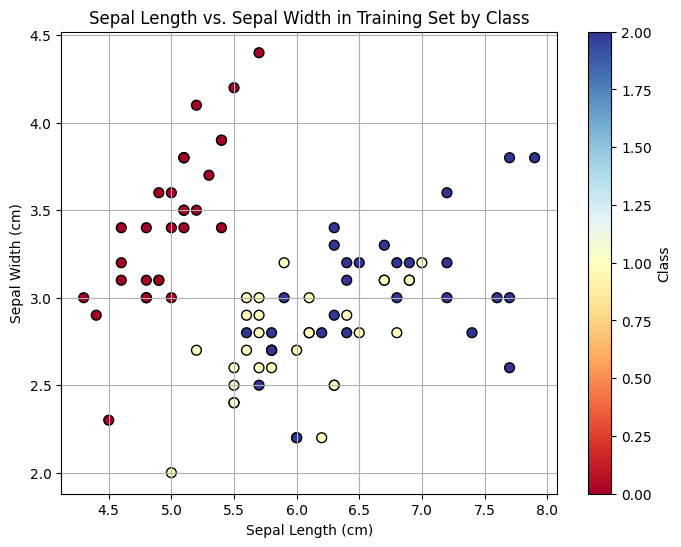

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.RdYlBu, edgecolor='k', s=50)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Sepal Length vs. Sepal Width in Training Set by Class')
plt.colorbar(label='Class')
plt.grid(True)
plt.show()

## Logistic Regression

Let's perform a classification using logistic regression:

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(solver='newton-cg',
                        multi_class='multinomial',
                        random_state=42)

lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


OK, how do we evaluate the classification? We can chose one of the [classification performance measures](http://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics).

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
)


print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.2f}")
print(f"Recall: {recall_score(y_test, y_pred, average='weighted'):.2f}")

Accuracy: 0.78
Precision: 0.78
Recall: 0.78


Or we use the classification report function:

In [ ]:
print('Classification Report:\n', classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       0.67      0.70      0.68        20
           2       0.68      0.65      0.67        20

    accuracy                           0.78        60
   macro avg       0.78      0.78      0.78        60
weighted avg       0.78      0.78      0.78        60



Finally, we would like to plot the decision regions and our data in order to see how the classifier categorized the events. We have highlighted the test data.

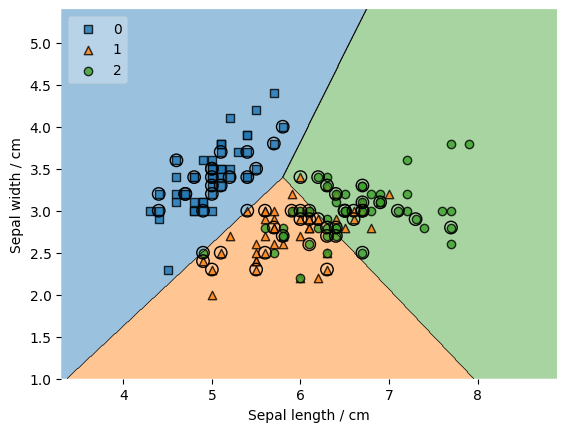

In [ ]:
from mlxtend.plotting import plot_decision_regions

ax = plot_decision_regions(X=X, y=y, clf=lr, X_highlight=X_test, legend=2)
ax.set(
    xlabel="Sepal length / cm",
    ylabel="Sepal width / cm",
);

## K-Nearest Neighbors

### Task 6 (Bonus): Perform a classification using [K-nearest neighbors classifier](http://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html), evaluate the performance and show the decision regions.

K-Nearest Neighbors Performance:
Accuracy: 0.83
Precision: 0.83
Recall: 0.83
Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98        20
           1       0.76      0.80      0.78        20
           2       0.78      0.70      0.74        20

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60



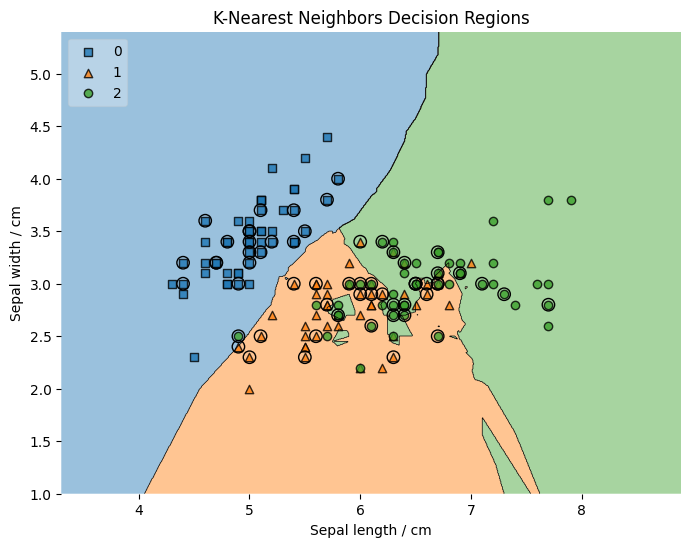

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt

# Initialize and train K-Nearest Neighbors classifier
knn = KNeighborsClassifier(n_neighbors=5, p=2, metric='minkowski')
knn.fit(X_train, y_train)

# Make predictions on the test set
y_pred_knn = knn.predict(X_test)

# Evaluate performance
print('K-Nearest Neighbors Performance:')
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.2f}")
print(f"Precision: {precision_score(y_test, y_pred_knn, average='weighted'):.2f}")
print(f"Recall: {recall_score(y_test, y_pred_knn, average='weighted'):.2f}")
print('Classification Report:\n', classification_report(y_test, y_pred_knn))

# Plot decision regions
plt.figure(figsize=(8, 6))
ax = plot_decision_regions(X=X, y=y, clf=knn, X_highlight=X_test, legend=2)
ax.set(xlabel="Sepal length / cm", ylabel="Sepal width / cm")
plt.title('K-Nearest Neighbors Decision Regions')
plt.show()


# Comparison of Performance
##Logistic Regression Performance:

Accuracy: 0.78  

Precision (weighted average): 0.78  

Recall (weighted average): 0.78  

**Class-wise F1-scores:**  

Class 0 (Iris-setosa): 1.00  

Class 1 (Iris-versicolor): 0.68  

Class 2 (Iris-virginica): 0.67

##K-Nearest Neighbors Performance:

Accuracy: 0.83  

Precision (weighted average): 0.83  

Recall (weighted average): 0.83  

**Class-wise F1-scores:**  

Class 0 (Iris-setosa): 0.98  

Class 1 (Iris-versicolor): 0.78  

Class 2 (Iris-virginica): 0.74  

**Comparison:**  

The K-Nearest Neighbors model shows better overall  
  
   performance with an accuracy, precision, and recall of 0.83,
    
  compared to 0.78 for Logistic Regression. This indicates that KNN  
   generally classifies more samples correctly.  


**Class-wise Performance:**

Both models perform exceptionally well for Class 0 (Iris-setosa),  
 which is typically linearly separable from the other two classes.   
 Logistic Regression achieves a perfect F1-score for this class,   
 while KNN is very close.  

For Class 1 (Iris-versicolor) and Class 2 (Iris-virginica), which   
are known to be less linearly separable and often overlap, KNN   
significantly outperforms Logistic Regression.   


The Logistic Regression model produces linear decision boundaries,   
which is characteristic of linear models. It struggles more where   
the classes overlap, resulting in some misclassifications in those   
areas.
The K-Nearest Neighbors model, being a non-parametric method,   
creates more flexible, non-linear decision boundaries. These   
boundaries better adapt to the local distribution of data points,   
allowing it to better separate the intertwined classes 1 and 2,   
which aligns with its higher performance metrics for these classes.
  
  In conclusion, for this particular dataset and using only sepal   
  length and sepal width, the K-Nearest Neighbors classifier   
  provides a more accurate classification than Logistic Regression,   
  especially in distinguishing between the Iris-versicolor and   
  Iris-virginica species due to its ability to create non-linear   
  decision boundaries.